# Sprint 6 - Análisis Exploratorio de Datos (Sesiones)

**Versión para estudiantes**

En el presente caso se busca aplicar los conocimientos adquiridos para el desarrollo de un primer tipo de análisis específico que todo analista o científico de datos debe realizar: **Análisis Exploratorio de Datos** (EDA por sus siglas en inglés). Este análisis tiene como propósito estudiar el comportamiento de indicadores o métricas específicas derivadas a partir de los datos disponibles, para lo cual emplea fundamentalmente dos herramientas:

* Estadística descriptiva: El área de la estadística enfocada en el resumen y presentación de variables a partir de valores.
* Visualización (lo cual ya lo has venido practicando en los capítulos anteriores).

Como puedes evidenciar, saber estadística te ayudará mucho en tu camino como analista o científico de datos. Te recomiendo por tanto que escuches este playlist sobre Fundamentos de Estadística creado por el canal StatQuest de Josh Starmer: https://youtube.com/playlist?list=PLblh5JKOoLUK0FLuzwntyYI10UQFUhsY9&si=fTrXd4SYsSvR_iVe.

## Entendimiento del contexto

El Banco Mundial es un organismo multinacional cuyo propósito es el brindar asistencia económica y financiera a sus estados asociados. Entre los servicios que ofrece se encuentra la de generar y publicar diversos indicadores macroeconómicos, sociales, demográficos y ambientales que permiten estudiar y contrastar la situación multidimensional entre países a través de los años. Si es de tu interés, puedes acceder a todo su catálogo de información en https://data.worldbank.org/.

Un dato importante para que tengas en cuenta es que a nivel mundial se reconocen poco más de 200 estados, de los cuales algunos proveen de información al Banco Mundial (estados miembro) y otros no lo hacen. La entidad si le es posible estima mediante modelos econométricos algunos de estos indicadores faltantes.

En este sentido, el Banco Mundial te ha contratado para que realices un análisis respecto al comportamiento de la variación del Producto Interno Bruto (PIB) entre los años 2000 y 2023. En concreto, esta entidad quiere que le asistas contestando las siguientes preguntas:

* ¿Cuál ha sido el comportamiento de este indicador en todo el período estudiado?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión (reducción del PIB) en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

## Entendimiento de los datos

La entidad te ha compartido la siguiente información en la que quiere que bases tu análisis:

* **cat_codpais3**: [264 filas, 2 columnas] Catálogo que contiene el nombre del país y sus siglas *Alpha-3* de acuerdo a la normativa ISO.
* **wb_ahorro**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje promedio de ahorro que mantienen los habitantes como porcentaje de su ingreso.
* **wb_crecimpib**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación del PIB.
* **wb_crecimpob**: [265, 25] Series anuales 2000 - 2023 por país respecto a la tasa de variación de la población.
* **wb_poburbana**: [265, 25] Series anuales 2000 - 2023 por país respecto al porcentaje de la población que reside en áreas urbanas.

Vale señalar que cada uno de estos dataframes se encuentra en formato *csv*.

Antes que nada vale que importes las librerías que vas a utilizar, esto es **pandas**, **numpy** y **matplotlib**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Vamos a importar además una librería llamada **Warnings**. Investiga para qué sirve esta librería y qué hace el siguiente código.

```py
import warnings
warnings.filterwarnings("ignore")
```

In [2]:
import warnings
warnings.filterwarnings("ignore")

Carga ahora los datos de todos los dataframes disponibles.

In [3]:
cat_pais = pd.read_csv("/content/cat_codpais3.csv", sep = ",")
df_ahorro = pd.read_csv("/content/wb_ahorro.csv")
df_pib = pd.read_csv("/content/wb_crecimpib.csv")
df_poblacion = pd.read_csv("/content/wb_crecimpob.csv")
df_urbana = pd.read_csv("/content/wb_poburbana.csv")

Crea una función que te permita mirar:

* La estructura general del dataset.
* Una muestra aleatoria de 5 filas en la que se presenten solamente las primeras 5 columnas del dataset.
* Un conteo de los duplicados existentes.

In [4]:
def fun_diagnostico (df):
    print("ESTRUCTURA GENERAL DE LA TABLA:")
    print(df.info())
    print("\n")
    print("MUESTRA DE LOS DATOS: ")
    print(df.sample(5).iloc[:,:5])
    print("\n")
    print(f"FILAS DUPLICADAS: {df.duplicated().sum()}")

Aplica la función creada en cada uno de los datasets del Banco Mundial.

In [5]:
fun_diagnostico(cat_pais)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  214 non-null    object
 1   country_name  214 non-null    object
dtypes: object(2)
memory usage: 3.5+ KB
None


MUESTRA DE LOS DATOS: 
    country_code country_name
81           HND     Honduras
63           FJI         Fiji
68           GBR  Reino Unido
205          VNM     Viet Nam
154          PRI  Puerto Rico


FILAS DUPLICADAS: 0


In [6]:
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          161 non-null    float64
 2   2001          160 non-null    float64
 3   2002          167 non-null    float64
 4   2003          169 non-null    float64
 5   2004          169 non-null    float64
 6   2005          187 non-null    float64
 7   2006          190 non-null    float64
 8   2007          195 non-null    float64
 9   2008          196 non-null    float64
 10  2009          198 non-null    float64
 11  2010          200 non-null    float64
 12  2011          201 non-null    float64
 13  2012          204 non-null    float64
 14  2013          204 non-null    float64
 15  2014          206 non-null    float64
 16  2015          207 non-null    float64
 17  2016          205 non-null    float64
 18

In [7]:
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          246 non-null    float64
 2   2001          247 non-null    float64
 3   2002          247 non-null    float64
 4   2003          251 non-null    float64
 5   2004          251 non-null    float64
 6   2005          251 non-null    float64
 7   2006          251 non-null    float64
 8   2007          252 non-null    float64
 9   2008          252 non-null    float64
 10  2009          255 non-null    float64
 11  2010          255 non-null    float64
 12  2011          255 non-null    float64
 13  2012          255 non-null    float64
 14  2013          255 non-null    float64
 15  2014          256 non-null    float64
 16  2015          256 non-null    float64
 17  2016          255 non-null    float64
 18

In [8]:
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          264 non-null    float64
 2   2001          264 non-null    float64
 3   2002          264 non-null    float64
 4   2003          264 non-null    float64
 5   2004          264 non-null    float64
 6   2005          264 non-null    float64
 7   2006          264 non-null    float64
 8   2007          264 non-null    float64
 9   2008          264 non-null    float64
 10  2009          264 non-null    float64
 11  2010          264 non-null    float64
 12  2011          264 non-null    float64
 13  2012          264 non-null    float64
 14  2013          264 non-null    float64
 15  2014          264 non-null    float64
 16  2015          264 non-null    float64
 17  2016          264 non-null    float64
 18

In [9]:
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   2000          262 non-null    float64
 2   2001          262 non-null    float64
 3   2002          262 non-null    float64
 4   2003          262 non-null    float64
 5   2004          262 non-null    float64
 6   2005          262 non-null    float64
 7   2006          262 non-null    float64
 8   2007          262 non-null    float64
 9   2008          262 non-null    float64
 10  2009          262 non-null    float64
 11  2010          262 non-null    float64
 12  2011          262 non-null    float64
 13  2012          262 non-null    float64
 14  2013          262 non-null    float64
 15  2014          262 non-null    float64
 16  2015          262 non-null    float64
 17  2016          262 non-null    float64
 18

Hagamos ahora un experimento, filtra los datos de variación del PIB de Estados Unidos (USA) de los años 2013 a 2019. Guarda estos datos en una variable.

In [10]:
pib_usa = df_pib.loc[df_pib["Country Code"] == "USA","2013":"2019"]
pib_usa

,2013,2014,2015,2016,2017,2018,2019
251,2.11783,2.52382,2.94555,1.819451,2.457622,2.966505,2.467038


Intenta ahora graficar estos datos con el método `plot` como usualmente lo has venido haciendo.

<Axes: >

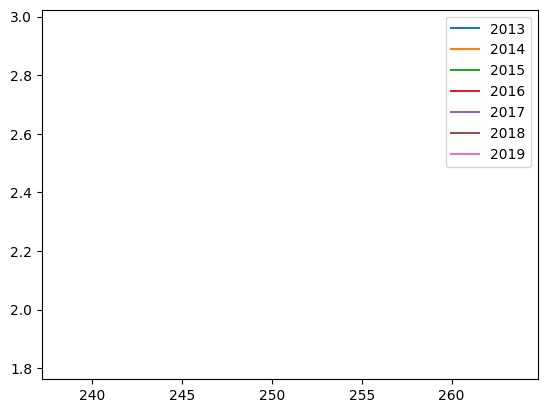

In [11]:
pib_usa.plot()

En cuanto a estos resultados notemos dos puntos importantes:

* Por una parte, el filtrado no es tan natural como usualmente lo hacemos. De hecho resultaría imposible en este punto responder esta pregunta usando el método `query`.
* Además no es posible graficar de forma directa y sencilla con el método `plot`.

Esto se explica porque el dataset **df_pib** (y todos los demás con excepción de **cat_pais**) es **ANCHO**. Un dataset ancho es aquel en que cada fila representa a una única entidad (en este caso un país) que no se repite en otras filas. Su utilidad radica en que esta presentación de datos es fácil de interpretar por usuarios "no analíticos", justamente porque se puede acceder a la totalidad información de cada entidad de forma rápida y directa.

Sin embargo, para usuarios "analíticos" como nosotros esta presentación no es adecuada, pues nosotros queremos tablas **LARGAS**. En una tabla larga cada fila representa una observación (o lo que es lo mismo un dato) con sus diferentes variables y particularidades, y facilita en consecuencia la manipulación y visualización de información.

Visto todo esto, define tu plan de acción para preparar estos datos.

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

* La tabla **cat_pais** no presenta novedades por lo que se debe mantener en su estado actual.
* Para las demás tablas:
    * Es necesario transformar su presentación para que sean tablas *largas* que permitan su uso analítico.
    * Los nombres de las columnas deben ajustarse a formato *snake_case*.
    * Hemos evidenciado que existen valores perdidos en los diferentes datasets, sin embargo dado el contexto puede que estos respondan en a diferentes situación dependiendo del país al cual se corresponden (i.e países sin ningún valor, países con un pequeño número de casos ausentes, etc.). Se debe por tanto tomar una decisión sobre como tratarlos una vez que sea posible filtrar esta información fácilmente.
* Una vez realizados estos pasos, conviene unir todos los datasets en una única tabla consolidada.

## Preparación de datos

Vamos a empezar con **df_pib**. Transforma la presentación ancha de esta tabla a una de tipo *larga* aplicando el método `melt` o la función `wide_to_long`.

In [12]:
df_pib = df_pib.melt(
    var_name = "year",
    value_name = "value",
    id_vars = "Country Code"
)

fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  6360 non-null   object 
 1   year          6360 non-null   object 
 2   value         6051 non-null   float64
dtypes: float64(1), object(2)
memory usage: 149.2+ KB
None


MUESTRA DE LOS DATOS: 
     Country Code  year     value
4945          NIC  2018 -3.363706
4902          LBY  2018  7.941368
4400          MMR  2016  5.862473
4794          BIH  2018  3.827499
6355          XKX  2023  3.337895


FILAS DUPLICADAS: 0


Ajusta los nombres de las columnas para que estos sigan el formato *snake_case*.

In [13]:
nombres = df_pib.columns
nombres_clean = []
for n in nombres:
  nombres_clean.append(n.lower().replace(" ","_"))
nombres_clean

['country_code', 'year', 'value']

In [14]:
df_pib.columns = nombres_clean
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6360 non-null   object 
 1   year          6360 non-null   object 
 2   value         6051 non-null   float64
dtypes: float64(1), object(2)
memory usage: 149.2+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year     value
81            GBR  2000  4.318727
5176          LSO  2019 -1.417994
1556          TEC  2005  6.643261
2309          PNG  2008 -0.296458
615           GIN  2002  5.164609


FILAS DUPLICADAS: 0


In [15]:
df_pib["year"] = df_pib["year"].astype(int)
pib_usa = df_pib[df_pib["country_code"] == "USA"]
pib_usa =pib_usa[(pib_usa["year"] >= 2013) & (pib_usa["year"] <= 2019)]
pib_usa

,country_code,year,value
3696,USA,2013,2.117830
3961,USA,2014,2.523820
4226,USA,2015,2.945550
4491,USA,2016,1.819451
4756,USA,2017,2.457622
5021,USA,2018,2.966505
5286,USA,2019,2.467038


<Axes: >

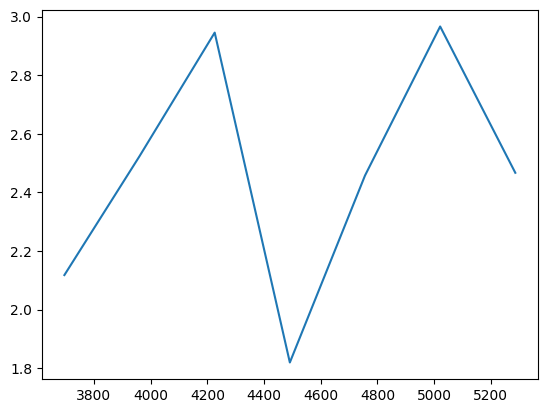

In [16]:
df_pib.query("country_code == 'USA' and 2013 <= year <= 2019")["value"].plot()

<Axes: >

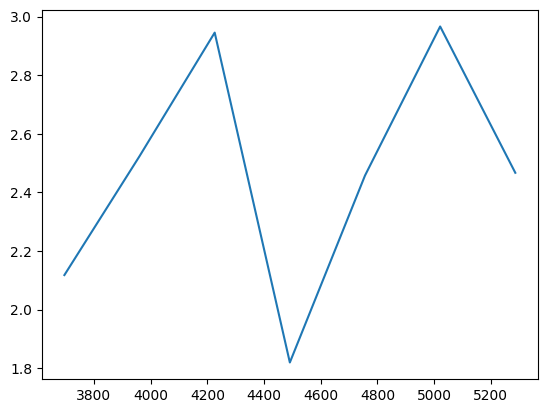

In [17]:
pib_usa["value"].plot()

In [18]:
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6360 non-null   object 
 1   year          6360 non-null   int64  
 2   value         6051 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 149.2+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year     value
964           MYS  2003  5.788499
4482          TTO  2016 -7.527137
2098          TUN  2007  6.709521
1593          AFW  2006  5.374762
670           LMY  2002  4.730828


FILAS DUPLICADAS: 0


Ya podemos estudiar los valores perdidos con esta tabla *larga*. Identifica diferentes tipologías de países en función de cuántos valores ausentes tengan.

In [19]:
# Obtener casos perdidos hay por pais
casos_perdidos = (
    df_pib[df_pib["value"].isna()]
    .groupby("country_code")
    .agg(casos = ("year", "count"))
)

casos_perdidos

,casos
country_code,
ABW,1
AFG,2
ASM,4
BMU,1
BTN,1
CHI,18
CUB,1
CUW,2
CYM,8


Podríamos dividir a los países en 2 grupos en base a sus valores ausentes:

* Aquellos que tienen menos de un 20% (aprox. 5) de años sin valores.
* El resto que posee más del 20% de valores perdidos.

Para el último caso que correspondería a los países con pocos o ningún dato relevante, elimina todos estos registros pues su información está limitada pudiendo distorsionar los análisis.

In [20]:
paises_eliminar = list(casos_perdidos.query("casos > 5").index)

In [21]:
df_pib = df_pib[~df_pib["country_code"].isin(paises_eliminar)]

Para el primer caso, en donde existen muchos datos relevantes, aplica una imputación por el valor mediano de dicho país considerando que esto no alterará significativamente los resultados de los análisis.

In [22]:
df_pib.sample(5)

,country_code,year,value
1087,BMU,2004,2.321267
1076,BDI,2004,4.833658
26,BLZ,2000,12.240614
246,TZA,2000,4.520785
1730,LMY,2006,8.207421


In [23]:
# Obtener mediana por pais
med_por_pais = (
    df_pib
    .groupby("country_code")
    .agg(med = ("value","median"))
)

med_por_pais

,med
country_code,
ABW,1.719625
AFE,3.532285
AFG,3.318073
AFW,5.172263
AGO,3.263339
...,...
WSM,3.321682
YEM,3.647569
ZAF,2.592734


In [24]:
# Incluir de forma temporal esta mediana en el dataset
df_pib = df_pib.merge(
    med_por_pais,
    on = "country_code"
)

In [25]:
df_pib.loc[500,"country_code"]

'AND'

In [26]:
# Imputar los valores perdidos por la mediana
for fila in range(df_pib.shape[0]):
  if np.isnan(df_pib.loc[fila, "value"]):
    df_pib.loc[fila, "value"] = df_pib.loc[fila, "med"]

In [27]:
# Quitar la columna med
df_pib = df_pib.drop(columns = "med")
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   object 
 1   year          5928 non-null   int64  
 2   value         5928 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 139.1+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year     value
4069          KIR  2016  7.224335
3580          LAO  2014  7.611963
3220          ARG  2013  2.405324
2758          CMR  2011  3.379211
1517          CAN  2006  2.637944


FILAS DUPLICADAS: 0


Concluye ejecutando los siguientes procedimientos de limpieza adicionales:

* Cambiar el tipo de variable de year a entero.
* Cambia el nombre de la columna value a algo más coherente con el contexto como *var_pib*.

In [28]:
df_pib["year"] = df_pib["year"].astype(int)
df_pib = df_pib.rename(columns = {"value":"var_pib"})
fun_diagnostico(df_pib)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   object 
 1   year          5928 non-null   int64  
 2   var_pib       5928 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 139.1+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year   var_pib
262           AZE  2001  9.900000
1484          AFG  2006  5.357403
3552          HTI  2014  2.888773
4942          AFG  2020 -2.351101
4045          HRV  2016  3.649198


FILAS DUPLICADAS: 0


Ahora bien, considera que este procedimiento debe repetirse exactamente igual en los datasets **df_ahorro**, **df_poblacion** y **df_urbana**. Haslo de forma **EFICIENTE**.

In [29]:
# Crear funcion para preparar datos
def fun_procesamiento (df, nombre_col):

  # Transformar a tabla larga
  df = df.melt(id_vars='Country Code', var_name="year", value_name="value")

  # Ajustar nombres de columnas a snake_case
  df.columns = [x.lower().replace(" ","_") for x in df.columns]

  # Dar tratamiento a valores perdidos
  casos_perdidos = (
        df[df['value'].isna()]
        .groupby("country_code")
        .agg(casos = ("country_code","count"))
        .sort_values(by = "casos",ascending=False)
        .reset_index()
    )

  paises_eliminar = list(casos_perdidos.query('casos > 5')["country_code"])

  df = df[~df['country_code'].isin(paises_eliminar)]

  med_por_pais = df.groupby('country_code').agg(med = ("value","median")).reset_index()

  df = df.merge(
      med_por_pais,
      on = "country_code",
  )

  for i in range(df.shape[0]):
      if np.isnan(df.loc[i,'value']):
          df.loc[i,'value'] = df.loc[i,"med"]

  df = df.drop(columns="med")

  #Ajustes finales
  df['year'] = df['year'].astype(int)

  df = df.rename(columns={"value":nombre_col})

  return df

In [30]:
# Procesar dataframe de ahorro
df_ahorro = fun_procesamiento(df_ahorro, "ahorro")
fun_diagnostico(df_ahorro)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3936 entries, 0 to 3935
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  3936 non-null   object 
 1   year          3936 non-null   int64  
 2   ahorro        3936 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 92.4+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year     ahorro
1623          THA  2009  29.274061
3074          POL  2018  19.518309
395           IBD  2002  29.776262
3764          UKR  2022  16.416376
3340          GTM  2020  18.532917


FILAS DUPLICADAS: 0


In [31]:
df_poblacion = fun_procesamiento(df_poblacion, "var_pob")
fun_diagnostico(df_poblacion)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6336 entries, 0 to 6335
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6336 non-null   object 
 1   year          6336 non-null   int64  
 2   var_pob       6336 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 148.6+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year   var_pob
5925          JOR  2022  1.226637
2278          MUS  2008  0.361631
468           SAU  2001  2.468601
4070          IRL  2015  0.944845
739           SMR  2002  2.292882


FILAS DUPLICADAS: 0


In [32]:
df_urbana = fun_procesamiento(df_urbana, "pct_urbana")

In [33]:
fun_diagnostico(df_urbana)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  6288 non-null   object 
 1   year          6288 non-null   int64  
 2   pct_urbana    6288 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 147.5+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year  pct_urbana
3240          HKG  2012     100.000
15            AZE  2000      51.386
2370          ATG  2009      26.818
1395          GIN  2005      32.257
121           KGZ  2000      35.298


FILAS DUPLICADAS: 0


Consolida la información de estos 4 datasets en una sola tabla de tal forma que se mantengan todas las filas de **df_pib** puesto que allí se encuentra la variable más importante dado el contexto.

In [34]:
df_consolidado = (
    df_pib
    .merge(
        df_ahorro,
        on = ["country_code","year"],
        how = "left"
    )
    .merge(
        df_poblacion,
        on = ["country_code","year"],
        how = "left"
    )
    .merge(
        df_urbana,
        on = ["country_code","year"],
        how = "left"
    )
)

fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5928 entries, 0 to 5927
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  5928 non-null   object 
 1   year          5928 non-null   int64  
 2   var_pib       5928 non-null   float64
 3   ahorro        3936 non-null   float64
 4   var_pob       5928 non-null   float64
 5   pct_urbana    5928 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 278.0+ KB
None


MUESTRA DE LOS DATOS: 
     country_code  year   var_pib     ahorro   var_pob
3434          TMN  2013  0.417305        NaN  1.979730
5825          MEA  2023  1.780040        NaN  1.522026
2489          BFA  2010  8.446282        NaN  2.939268
2072          IBD  2008  5.905424  37.449411  1.006440
1725          YEM  2006  3.170409        NaN  2.983230


FILAS DUPLICADAS: 0


Incorpora ahora en esta información el nombre de los paises de forma que se garantice que no existan valores perdidos en la columna country_name.

In [35]:
df_consolidado = cat_pais.merge(
    df_consolidado,
    on = "country_code"
)

fun_diagnostico(df_consolidado)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4704 entries, 0 to 4703
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  4704 non-null   object 
 1   country_name  4704 non-null   object 
 2   year          4704 non-null   int64  
 3   var_pib       4704 non-null   float64
 4   ahorro        3144 non-null   float64
 5   var_pob       4704 non-null   float64
 6   pct_urbana    4704 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 257.4+ KB
None


MUESTRA DE LOS DATOS: 
     country_code country_name  year    var_pib     ahorro
2859          MMR      Myanmar  2003  13.843997        NaN
3303          PAK     Pakistan  2015   4.217942  14.944265
3975          SVN    Eslovenia  2015   2.210082  23.089995
3469          PRI  Puerto Rico  2013  -0.306827        NaN
343           BEL      Belgica  2007   3.676881  28.779585


FILAS DUPLICADAS: 0


In [36]:
df_consolidado.query("country_name == 'Alemania'")

,country_code,country_name,year,var_pib,ahorro,var_pob,pct_urbana
1152,DEU,Alemania,2000,2.912503,22.668918,0.135432,74.965
1153,DEU,Alemania,2001,1.681468,22.540648,0.168225,75.170
1154,DEU,Alemania,2002,-0.197974,22.639590,0.168128,75.374
1155,DEU,Alemania,2003,-0.700117,21.796395,0.055363,75.577
1156,DEU,Alemania,2004,1.175088,24.320947,-0.021710,75.779
1157,DEU,Alemania,2005,0.731707,24.130960,-0.056778,75.980
1158,DEU,Alemania,2006,3.816442,26.338422,-0.112797,76.179
1159,DEU,Alemania,2007,2.976455,28.267438,-0.133719,76.378
1160,DEU,Alemania,2008,0.959879,27.148700,-0.190143,76.575
1161,DEU,Alemania,2009,-5.693836,24.396839,-0.253383,76.771


## Análisis exploratorio de datos

Como ya se mencionó, el EDA busca estudiar el comportamiento de indicadores concretos mediante la aplicación de técnicas estadísticas y visualización. En este sentido conviene recordar que la principal métrica de interés en el contexto de este caso es la **variación del pib**, ante la cual se han planteado las siguientes preguntas:

* ¿Cuál ha sido el comportamiento de este indicador en todo el período estudiado?
* ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?
* ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?
* ¿Existen diferencias significativas en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

### ¿Cuál ha sido el comportamiento de la variación en el PIB en todo el período estudiado?

Estudia la distribución del indicador mediante un resumen estadístico. Recuerda que la distribución de una variable hace referencia a sus siguientes características fundamentales:

1. Su nivel de centralidad.
2. Su grado de dispersión o volatilidad.
3. La existencia de valores atípicos.
4. La existencia de sesgos.  

In [37]:
df_consolidado["var_pib"].describe()

,var_pib
count,4704.000000
mean,3.412050
std,6.046843
min,-58.318230
25%,1.220359
50%,3.508704
75%,5.823506
max,153.492641


Utiliza el criterio *3-sigma* para establecer el rango de variación de PIB de un país cualquiera con un 99% de confianza.

In [38]:
lim_info = df_consolidado ["var_pib"].mean() -3 * df_consolidado["var_pib"].std()
lim_sup = df_consolidado ["var_pib"].mean() +3 * df_consolidado["var_pib"].std()
print(f"un país cualquier en un año tendrá una variación del PIB entre {lim_info:.1f}% y {lim_sup:.1f}%")

un país cualquier en un año tendrá una variación del PIB entre -14.7% y 21.6%


Complementa este resultado con un diagrama de cajón con bigotes.

<Axes: >

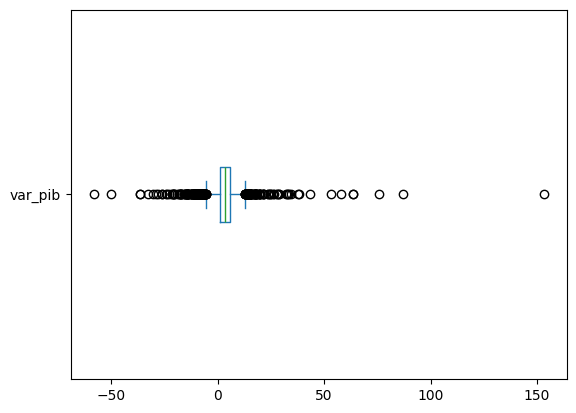

In [39]:
df_consolidado.plot(
    kind = "box",
    y = "var_pib",
    vert = False
)

Para una mejor visualización de la distribución, repite el gráfico excluyendo los valores atípicos.

<Axes: >

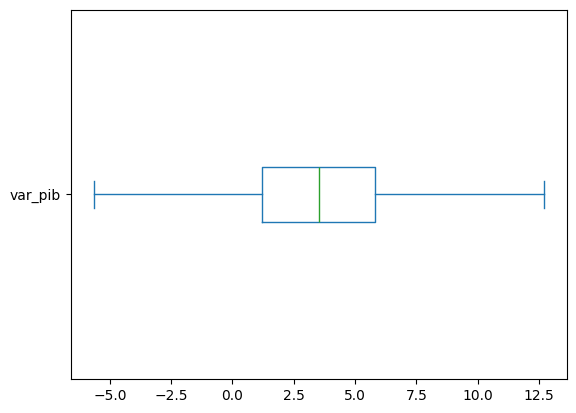

In [40]:
df_consolidado.plot(
    kind = "box",
    y = "var_pib",
    vert = False,
    showfliers = False
)

Vale señalar que un valor se considera atípico si el mismo NO se encuentra dentro del intervalo

$$ \left[ Q_1 - 1.5(Q3-Q1),\; Q_3 + 1.5(Q3-Q1)\right]$$

donde $Q1$ es el primer cuartil y $Q3$ el tercero.

Complementa ahora este resultado con un histograma tal que cumplas con lo siguiente:

* Excluye del dataset los casos atípicos.
* Utiliza un número de columnas ($c$) pertinente para lo cual puedes utilizar la fórmula $c \approx \sqrt{n}$, donde $n$ es el número de observaciones no atípicas.

In [41]:
#Ecluir los valores atípicos
umbral_inf = df_consolidado["var_pib"].quantile(.25) - 1.5 * (df_consolidado["var_pib"].quantile(0.75)- df_consolidado["var_pib"].quantile(0.25))
umbral_sup = df_consolidado["var_pib"].quantile(.75) + 1.5 * (df_consolidado["var_pib"].quantile(0.75)- df_consolidado["var_pib"].quantile(0.25))
df_sin_atipicos = df_consolidado.query("var_pib >= @umbral_inf and var_pib <= @@umbral_sup")

El histograma puede resumirse en un diagrama de densidad. Créalo.

<Axes: ylabel='Frequency'>

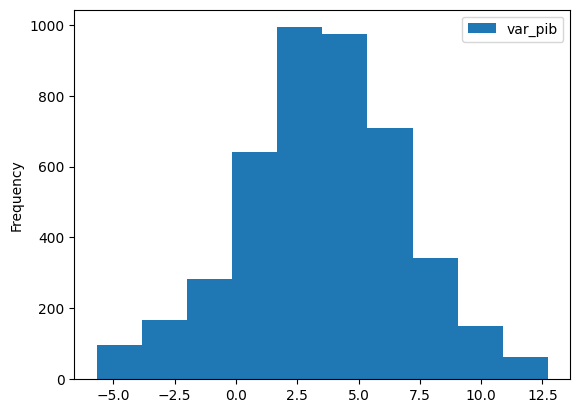

In [42]:
# Crear el histograma
df_sin_atipicos.plot(
    kind = "hist",
    y = "var_pib"
)

<Axes: ylabel='Density'>

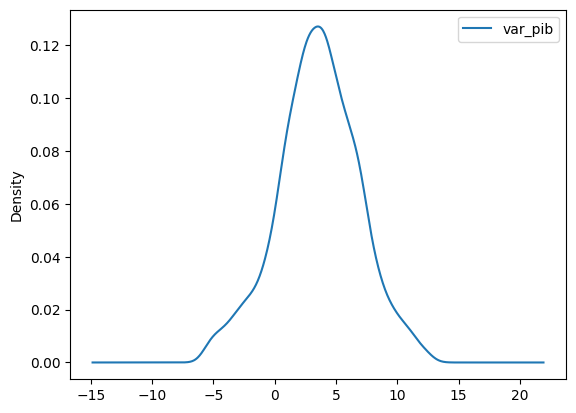

In [43]:
df_sin_atipicos.plot(
    kind ="density",
    y = "var_pib"
)

Genera finalmente un gráfico con la evolución a través de los años de la variación en el PIB promedio mundial.

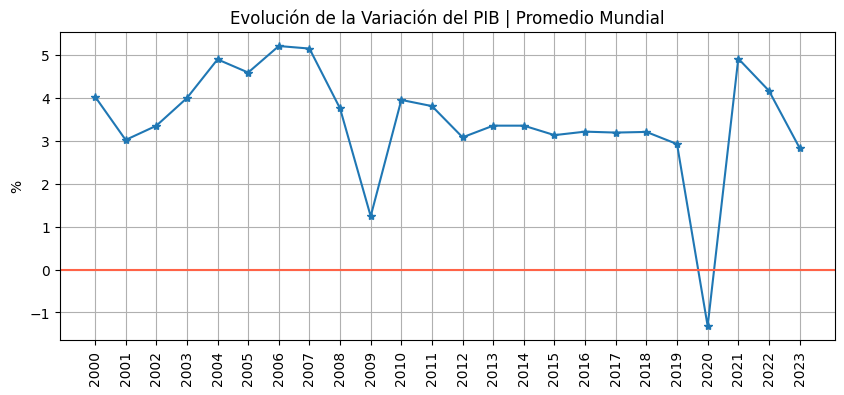

In [44]:
pib_anual = (
    df_sin_atipicos
    .groupby("year")
    .agg(var_pib = ("var_pib","mean"))
)
pib_anual.plot(
    figsize = [10,4],
    legend = None,
    marker = "*",
    xticks = range(2000,2024),
    rot = 90,
    grid = True,
    title = "Evolución de la Variación del PIB | Promedio Mundial",
    xlabel = "",
    ylabel = "%"
)
plt.axhline(y = 0, color = "tomato")

**CONCLUSIONES**

< Aquí tu respuesta >

### ¿Qué variables inciden principalmente en los cambios a nivel de este indicador?

In [45]:
df_sin_atipicos

,country_code,country_name,year,var_pib,ahorro,var_pob,pct_urbana
0,ABW,Aruba,2000,7.622921,23.714643,2.539234,46.717
1,ABW,Aruba,2001,4.182002,19.189309,1.768757,46.339
2,ABW,Aruba,2002,-0.944953,12.207159,1.194718,45.972
3,ABW,Aruba,2003,1.110505,14.646462,0.997396,45.606
4,ABW,Aruba,2004,7.293728,17.248334,0.900989,45.240
...,...,...,...,...,...,...,...
4697,ZWE,Zimbabwe,2017,4.080264,NaN,2.043620,32.237
4698,ZWE,Zimbabwe,2018,5.009867,NaN,2.020537,32.209
4701,ZWE,Zimbabwe,2021,8.468017,NaN,2.045715,32.303
4702,ZWE,Zimbabwe,2022,6.522375,NaN,2.024036,32.395


Excluye del dataset los años 2009 y 2020 por ser especiales en cuanto a la situación mundial vivida en esos períodos.

In [46]:
per_excluir =[2009,2020]
df_sin_atipicos = df_sin_atipicos.query("year ! = @per_excluir")

Estudia el grado de correlación existente entre las distintas métricas que tienes disponibles. Recuerda que la correlación mide el grado de vinculación lineal existente entre un par de variables, tal que:

* Si su valor es cercano a -1, se dice que ambas variables mantiene una relación **inversamente proporcional**, esto es, cuando una se incrementa la otra disminuye.
* Si su valor es cercano a +1, se dice que ambas variables mantiene una relación **directamente proporcional**, esto es, cuando una se incrementa la otra igualmente aumenta.
* Si su valor es cercano a 0, se dice que ambas variables no tienen relación estadística alguna.

In [47]:
df_sin_atipicos[["var_pib", "ahorro", "var_pob", "pct_urbana"]].corr()

,var_pib,ahorro,var_pob,pct_urbana
var_pib,1.000000,0.133361,0.177466,-0.195495
ahorro,0.133361,1.000000,0.053777,0.216421
var_pob,0.177466,0.053777,1.000000,-0.227735
pct_urbana,-0.195495,0.216421,-0.227735,1.000000


Repite el cálculo pero ahora utiliza los promedios anuales de cada indicador.

In [49]:
prom_anuales = df_sin_atipicos.groupby("year")[["var_pib", "ahorro", "var_pob", "pct_urbana"]].mean()
mat_corr = prom_anuales.corr()
mat_corr

,var_pib,ahorro,var_pob,pct_urbana
var_pib,1.000000,0.612344,0.175666,-0.293593
ahorro,0.612344,1.000000,0.101076,0.121394
var_pob,0.175666,0.101076,1.000000,-0.764582
pct_urbana,-0.293593,0.121394,-0.764582,1.000000


Visualiza la relación existente entre ahorro y var_pib mediante una gráfica de dispersión.

<Axes: xlabel='ahorro', ylabel='var_pib'>

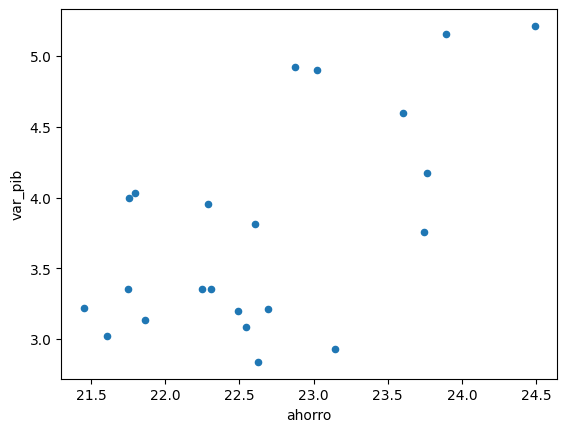

In [51]:
prom_anuales.plot(
    kind = "scatter",
    x = "ahorro",
    y = "var_pib"
)

Visualiza ahora la relación existente entre pct_urbana y var_pib mediante una gráfica de dispersión.

<Axes: xlabel='pct_urbana', ylabel='var_pib'>

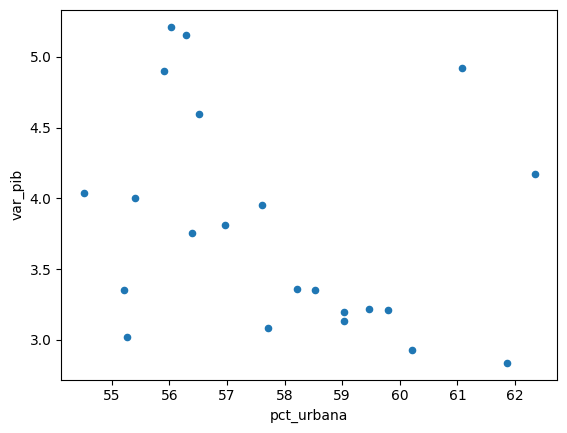

In [52]:
prom_anuales.plot(
    kind = "scatter",
    x = "pct_urbana",
    y = "var_pib"
)

**CONCLUSIONES**

< Aquí tu respuesta >

### ¿Qué tan probable es que un país tenga una recesión en un año cualquiera?

Crea una nueva columna en el dataset de forma que se evidencien los casos en los que han existido recesiones.

In [54]:
df_sin_atipicos["es_recesion"] = False
for fila in df_sin_atipicos.index:
  if df_sin_atipicos.loc[fila,"var_pib"] > 0:
    df_sin_atipicos.loc[fila,"es_recesion"] = False
  else:
    df_sin_atipicos.loc[fila,"es_recesion"] = True
df_sin_atipicos.sample(15)


,country_code,country_name,year,var_pib,ahorro,var_pob,pct_urbana,es_recesion
4321,TUV,Tuvalu,2001,0.000000,NaN,-0.176541,46.429,True
12,ABW,Aruba,2012,-1.040800,5.750848,0.810231,42.957,True
3413,PNG,Papua Nueva Guinea,2005,6.344796,NaN,3.215603,13.109,False
4048,SYC,Seychelles,2016,12.117527,7.389920,1.337635,55.831,False
2216,KEN,Kenya,2008,0.232283,15.404857,2.978845,22.800,False
497,BHS,Bahamas,2017,2.799519,15.796899,0.765794,82.925,False
1060,CUB,Cuba,2004,5.770538,NaN,0.232576,76.041,False
2779,MHL,Islas Marshall,2019,10.357829,NaN,-2.780253,77.417,False
389,BFA,Burkina Faso,2005,8.661873,NaN,3.148993,21.537,False
1637,GNB,Guinea-Bissau,2005,6.559771,6.220373,2.398893,38.157,False


Calcula en cuántos casos del dataset han existido recesiones y guarda este resultado en una variable llamada `casos_exitosos`.

In [58]:
casos = df_sin_atipicos ["es_recesion"].value_counts()
casos_exitosos = casos[1]

In [60]:
casos

,count
es_recesion,
False,3703
True,423


Guarda la totalidad de casos posibles en la variable `casos_totales`.

In [61]:
casos_totales = casos.sum()
print(casos_totales)

4126


Calcula la probabilidad de que en un año cualquiera un país entre en recesión. Recuerda que una probabilidad se mide como la razón entre los casos de éxito (eventos en los que sucede algo que estamos queriendo medir) y los casos totales observados. Además, una probabilidad debe cumplir 3 condiciones:

1. Es positiva, es decir, todo evento *puede* suceder.
2. Es estrictamente menor o igual a 1, es decir, existen otros eventos *posibles*.
3. La suma de todas las probabilidades de eventos posibles en un experimento es igual a 1, es decir, alguno *debe* suceder.

In [62]:
print(casos_exitosos/casos_totales)

0.10252060106640815


Vale que notes que esta probabilidad obtenida podría calcularse de forma directa con el siguiente código:

```py
prob_recesion = df_sin_atipicos["es_recesion"].mean()
```

Piensa el porqué esto funciona.

Encuentra el top 10 de países con una mayor probabilidad de recesión.

In [65]:
df_sin_atipicos.groupby("country_name")["es_recesion"].mean().sort_values(ascending = False).head(10)

,es_recesion
country_name,
Samoa Americana,0.619048
Puerto Rico,0.545455
Libia,0.428571
Bermudas,0.409091
Micronesia (Estados Federados de),0.409091
Argentina,0.380952
Palau,0.380952
Tuvalu,0.380952
Barbados,0.380952


**CONCLUSIONES**

* En promedio, un año malo en términos económicos para un país puede presentarse una vez por cada década. De manera consecuente se pueden esperar ciclos de alrededor de 9 años de crecimiento sostenido en las economías nacionales, ante lo cual las políticas de desarrollo e inversión pública y privada deberían alinearse a esta realidad observada para así garantizar que las variaciones positivas en el PIB sean las máximas posibles en estos años.
* Resalta que entre los 10 países con mayor probabilidad de recesión, 5 sean de la región del Caribe. Lo anterior, da cuenta de la necesidad para el Banco Mundial de fortalecer su  asistencia en esta zona geográfica. De igual manera otros 3 estados rankeados pertenecen a Oceanía que igualmente debería ser considerado en la planificación de actividades futuras de la entidad.

### ¿Existen diferencias en el crecimiento de países de "bajo desarrollo" frente a países de "alto desarrollo"?

Escoge 5 países que consideres de bajo desarrollo (i.e Ecuador, Bolivia, Guatemala, etc.), y 5 que consideres de alto desarrollo (i.e Estados Unidos, Alemania, Japón, etc.). Filtra el dataset de forma que solamente conserves estos países y adiciona una nueva columna que distinga a los dos grupos.  

Estudia comparativamente la distribución de var_pib en los países de alto y bajo desarrollo.

Los resultados aquí alcanzados parecerían indicar que en promedio la variación del PIB en países de bajo desarrollo es mayor a aquella de los países de alto desarrollo.

¿Cómo podemos estar completamente seguros de esta afirmación? La respuesta radica en la **Inferencia estadística**, cuyas técnicas nos permiten verificar hipótesis de forma objetiva y robusta. Investiga acerca de esta temática con enfoque en los siguientes conceptos:

* Pruebas de hipótesis
* Intervalos de confianza

**CONCLUSIONES**

< Aquí tu respuesta >